In [1]:
from typing import Dict, List
from collections import defaultdict
import os
from dataclasses import dataclass
import time
import copy

import numpy as np
import polars as pl
import torch
import torch.nn.functional as F
from torch import nn, Tensor
from torch.nn.utils.rnn import pad_sequence
from transformers import get_cosine_schedule_with_warmup
from datasets import load_dataset

In [2]:
DATA_DIR = "."
TOPK = 100
CORE_MIN_INTERACTIONS_PER_ITEM = 5
TEST_INTERVAL_SECONDS = 7 * 24 * 60 * 60
VALID_INTERVAL_SECONDS = TEST_INTERVAL_SECONDS
TEMPORAL_THRESHOLD = 25_395_195

np.random.seed(42)

ds = load_dataset("yandex/yambda", data_dir="flat/5b", data_files="likes.parquet")

interactions = ds['train'].to_polars()

core_items = (
    interactions
    .group_by("item_id")
    .agg(pl.len().alias("count"))
    .filter(pl.col("count") >= CORE_MIN_INTERACTIONS_PER_ITEM)
    .select("item_id")
)

data = interactions.join(core_items, on="item_id", how="semi")

VALID_START = TEMPORAL_THRESHOLD - VALID_INTERVAL_SECONDS
VALID_END = TEMPORAL_THRESHOLD
TEST_START = TEMPORAL_THRESHOLD
TEST_END = TEMPORAL_THRESHOLD + TEST_INTERVAL_SECONDS

train = data.filter(pl.col("timestamp") < VALID_START)
valid = data.filter(
    (pl.col("timestamp") >= VALID_START) &
    (pl.col("timestamp") < VALID_END)
)
test = data.filter(
    (pl.col("timestamp") >= TEST_START) &
    (pl.col("timestamp") < TEST_END)
)

train_users = train.select("uid").unique()
valid = valid.join(train_users, on="uid", how="semi")

pre_test_users = data.filter(pl.col("timestamp") < TEST_START).select("uid").unique()
test = test.join(pre_test_users, on="uid", how="semi")

valid_targets_df = (
    valid
    .select(["uid", "item_id"])
    .unique(subset=["uid", "item_id"], maintain_order=True)
    .group_by("uid", maintain_order=True)
    .agg(pl.col("item_id"))
)
valid_targets = dict(valid_targets_df.iter_rows())

test_targets_df = (
    test
    .select(["uid", "item_id"])
    .unique(subset=["uid", "item_id"], maintain_order=True)
    .group_by("uid", maintain_order=True)
    .agg(pl.col("item_id"))
)
test_targets = dict(test_targets_df.iter_rows())

In [3]:
def get_metrics(targets: List[int], candidates: List[int], topk: int) -> Dict[str, float]:
    candidates = candidates[:topk]

    target_set = set(targets)
    denom = min(len(target_set), topk)

    hits = np.array([1.0 if item in target_set else 0.0 for item in candidates], dtype=np.float64)

    hitrate = float(hits.sum() > 0)
    recall = float(hits.sum() / denom)

    discounts = 1.0 / np.log2(np.arange(2, topk + 2, dtype=np.float64))
    dcg = (hits * discounts).sum()
    idcg = discounts[:denom].sum()
    ndcg = dcg / idcg if idcg > 0 else 0.0

    return {"hitrate": hitrate, "recall": recall, "ndcg": ndcg}


def evaluate(
    targets: Dict[int, List[int]],
    candidates: Dict[int, List[int]],
    catalog_size: int,
    topk: int = 100,
) -> Dict[str, float]:
    if len(targets) == 0:
        return {
            "hitrate": 0.0,
            "recall": 0.0,
            "ndcg": 0.0,
            "coverage": 0.0,
        }

    metrics_sum = defaultdict(float)
    recommended_items = set()

    for uid, user_targets in targets.items():
        user_candidates = candidates[uid][:topk]

        m = get_metrics(user_targets, user_candidates, topk=topk)
        for name, value in m.items():
            metrics_sum[name] += value
        recommended_items.update(user_candidates)

    num_users = len(targets)
    out = {name: value / num_users for name, value in metrics_sum.items()}
    out["coverage"] = len(recommended_items) / catalog_size
    return out


def _to_python_float(value):
    if torch.is_tensor(value):
        return float(value.detach().cpu())
    return float(value)


def format_metrics(metrics: Dict[str, float]) -> str:
    return ", ".join(f"{name}={_to_python_float(value):.6f}" for name, value in metrics.items())


In [4]:
VOCAB_ITEMS = 60_000

item_to_token_id = (
    train
    .group_by("item_id")
    .agg(pl.len().alias("count"))
    .sort(by=["count", "item_id"], descending=[True, False])
    .head(VOCAB_ITEMS)
    .with_row_index(name="token_id")
    .with_columns([
        (pl.col("token_id") + 1).cast(pl.Int64).alias("token_id"),
    ])
    .select(["item_id", "token_id"])
)

In [5]:
MAX_EVENTS_PER_USER = 100

train_events = train.join(item_to_token_id, on="item_id", how="inner").sort("timestamp").with_columns([pl.col("token_id").cast(pl.Int64)])
train_events = train_events.group_by("uid", maintain_order=True).tail(MAX_EVENTS_PER_USER - 1)
train_histories = pl.concat([
        train_events
        .select("uid")
        .unique(maintain_order=True)
        .with_columns(pl.lit(0, dtype=pl.Int64).alias("token_id")),

        train_events.select([
            pl.col("uid"),
            pl.col("token_id").cast(pl.Int64),
        ]),
    ]).group_by("uid", maintain_order=True).agg(pl.col("token_id"))

In [6]:
@dataclass
class TrainingBatch:
    inputs: torch.Tensor
    targets: torch.Tensor
    size: int


class TrainingDataset:
    def __init__(
            self,
            df: pl.DataFrame,
            batch_size: int,
            seq_len: int,
            device: str = "cuda",
            chunk_rows: int = 64_000,
            shuffle: bool = True,
            seed: int | None = 42,
            pin_memory: bool = True
    ):
        self.df = df
        self.batch_size = batch_size
        self.seq_len = seq_len
        self.device = device
        self.chunk_rows = chunk_rows
        self.shuffle = shuffle
        self.seed = seed
        self.pin_memory = pin_memory

        self.batch_num_tokens = batch_size * seq_len + 1
        self.total_num_tokens = int(self.df.get_column("token_id").list.len().sum())

    def __len__(self):
        return self.total_num_tokens // self.batch_num_tokens

    def __iter__(self):
        df = self.df
        if self.shuffle:
            df = df.sample(fraction=1.0, shuffle=True, seed=self.seed)

        buf = np.empty(self.batch_num_tokens, dtype=np.int64)
        fill = 0

        for start in range(0, df.height, self.chunk_rows):
            chunk = df.slice(start, self.chunk_rows)
            tokens = chunk.explode("token_id").get_column("token_id").to_numpy()

            pos = 0
            while pos < len(tokens):
                need = self.batch_num_tokens - fill
                take = min(need, len(tokens) - pos)
                buf[fill:fill + take] = tokens[pos:pos + take]
                fill += take
                pos += take

                if fill == self.batch_num_tokens:
                    t = torch.as_tensor(buf.copy(), dtype=torch.long)
                    if self.pin_memory and self.device != "cpu":
                        t = t.pin_memory()
                    t = t.to(self.device, non_blocking=self.pin_memory and self.device != "cpu")

                    inputs = t[:-1].view(self.batch_size, self.seq_len)
                    targets = t[1:].view(self.batch_size, self.seq_len)
                    yield TrainingBatch(inputs, targets, size=inputs.numel())
                    fill = 0

In [7]:
dataloader = TrainingDataset(train_histories, batch_size=1024, seq_len=100, shuffle=True, device='cuda')

In [8]:
class SASRec(nn.Module):
    def __init__(
        self,
        num_items,
        emb_dim=128,
        max_seq_len=256,
        num_layers=2,
        num_heads=4,
        dropout=0.0
    ):
        super().__init__()
        self.item_embeddings = nn.Embedding(num_items + 1,emb_dim,)
        self.position_embeddings = nn.Embedding(max_seq_len, emb_dim)

        self.layernorm = nn.LayerNorm(emb_dim)
        self.dropout = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=num_heads,
            dim_feedforward=4 * emb_dim,
            dropout=dropout,
            activation=nn.GELU(),
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self._init_weights()
    
    @torch.no_grad()
    def _init_weights(self, initializer_range = 0.02):
        for key, value in self.named_parameters():
            if 'weight' in key:
                if 'norm' in key:
                    nn.init.ones_(value.data)
                else:
                    nn.init.trunc_normal_(
                        value.data, std=initializer_range, a=-2 * initializer_range, b=2 * initializer_range
                    )
            else:
                assert 'bias' in key
                nn.init.zeros_(value.data)

    def last_pooling(self, embeddings, mask):
        mask = mask.to(torch.bool)
        flatten_embeddings = embeddings[mask]
        lengths = torch.sum(mask, dim=-1)
        offsets = torch.cumsum(lengths, dim=0) 
        last_embeddings = flatten_embeddings[offsets.long() - 1]
        return last_embeddings

    def forward(self, inputs, attn_mask):
        embeds = self.item_embeddings(inputs)
        bs, num_embs, embs_dim = embeds.shape
        
        positions = torch.arange(start=0, end=num_embs, step=1, device=embeds.device)
        pos_embeds = self.position_embeddings(positions)
        embeds = embeds + pos_embeds
        embeds = self.dropout(self.layernorm(embeds))
        
        mask = torch.triu(torch.ones(num_embs, num_embs, device=embeds.device, dtype=torch.bool), diagonal=1)
        embeds = self.encoder(embeds, mask=mask)
        return embeds, self.last_pooling(embeds, attn_mask)

In [9]:
class Graph(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        max_seq_len: int,
        n_layers: int = 2,
        d_model: int = 128,
        n_heads: int = 4,
        dropout: float = 0.0,
        temperature: float = 1.0,
        normalize: bool = False,
        item_sampling_probs: torch.Tensor | None = None,
        logq_eps: float = 1e-12,
    ):
        super().__init__()

        self.vocab_size = vocab_size
        self.temperature = temperature
        self.normalize = normalize
        self.logq_eps = logq_eps

        self.sasrec = SASRec(
            num_items=vocab_size - 1,
            emb_dim=d_model,
            max_seq_len=max_seq_len,
            num_layers=n_layers,
            num_heads=n_heads,
            dropout=dropout,
        )

        if item_sampling_probs is None:
            self.register_buffer("item_sampling_probs", torch.empty(0, dtype=torch.float32))
        else:
            probs = torch.as_tensor(item_sampling_probs, dtype=torch.float32)
            if probs.numel() != vocab_size:
                raise ValueError("item_sampling_probs должен иметь длину vocab_size")
            self.register_buffer("item_sampling_probs", probs)

    @staticmethod
    def _get(batch, key, default=None):
        if isinstance(batch, dict):
            return batch.get(key, default)
        return getattr(batch, key, default)

    @staticmethod
    def lengths_to_mask(lengths: torch.Tensor, max_len: int) -> torch.Tensor:
        pos = torch.arange(max_len, device=lengths.device)
        return pos.unsqueeze(0) < lengths.unsqueeze(1)

    def forward(self, batch) -> torch.Tensor:
        inputs = self._get(batch, "inputs")
        labels = self._get(batch, "labels")
        if labels is None:
            labels = self._get(batch, "targets")

        mask = self._get(batch, "mask")
        if mask is None:
            mask = labels != 0
        mask = mask.to(torch.bool)

        attn_mask = torch.ones_like(inputs, dtype=torch.bool, device=inputs.device)
        seq_embeds, _ = self.sasrec(inputs, attn_mask)

        seq_embeds = seq_embeds.reshape(-1, seq_embeds.size(-1))
        pos_ids = labels.reshape(-1)
        valid = mask.reshape(-1) & (pos_ids != 0)

        seq_embeds = seq_embeds[valid]
        pos_ids = pos_ids[valid]

        unique_pos_ids, target_idx, counts = torch.unique(
            pos_ids,
            sorted=False,
            return_inverse=True,
            return_counts=True,
        )

        item_embeds = self.sasrec.item_embeddings(unique_pos_ids)

        if self.normalize:
            seq_embeds = F.normalize(seq_embeds, dim=-1)
            item_embeds = F.normalize(item_embeds, dim=-1)

        logits = (seq_embeds @ item_embeds.T) / self.temperature

        loss = F.cross_entropy(logits, target_idx)
        return loss

    @torch.no_grad()
    def predict_logits(
        self,
        token_ids: torch.Tensor,
        lengths: torch.Tensor | None = None,
        attn_mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        if attn_mask is None:
            if lengths is not None:
                attn_mask = self.lengths_to_mask(lengths, token_ids.size(1))
            else:
                attn_mask = token_ids != 0

        _, pooled = self.sasrec(token_ids, attn_mask)

        item_matrix = self.sasrec.item_embeddings.weight
        if self.normalize:
            pooled = F.normalize(pooled, dim=-1)
            item_matrix = F.normalize(item_matrix, dim=-1)

        logits = (pooled @ item_matrix.T) / self.temperature
        logits[:, 0] = -torch.inf
        return logits

In [10]:
def train_loop(
    graph,
    train_dataloader,
    log_dir: str | None = None,
    optimizer=None,
    scheduler=None,
    num_epochs: int = 1,
    grad_accum_steps: int = 1,
    grad_clip: float = 0.0,
    eval_every: int = -1,
    validation_func=None,
    selection_metric: str = "ndcg",
    print_every: int | None = None,
):
    if optimizer is None:
        raise ValueError("optimizer must be provided")

    graph.train()
    tokens_passed = 0
    global_step = 0
    history = []
    base_graph = getattr(graph, "_orig_mod", graph)

    best_metric_value = float("-inf")
    best_state_dict = None
    best_epoch = None

    num_batches = len(train_dataloader)
    if print_every is None:
        print_every = max(1, num_batches // 5)

    for epoch in range(num_epochs):
        train_it = iter(train_dataloader)
        epoch_loss_sum = 0.0
        epoch_tokens = 0
        epoch_start_time = time.time()

        print(f"\nEpoch {epoch + 1}/{num_epochs}")

        for batch_idx in range(num_batches):
            if torch.cuda.is_available():
                torch.cuda.synchronize()
            train_step_t0 = time.time()

            optimizer.zero_grad(set_to_none=True)

            train_loss = 0.0
            curr_tokens = 0

            for _ in range(grad_accum_steps):
                batch = next(train_it)
                curr_tokens += batch.size

                with torch.autocast("cuda", torch.bfloat16):
                    loss = graph(batch)

                loss = loss / grad_accum_steps
                train_loss += float(loss.detach())
                loss.backward()

            if grad_clip > 0.0:
                grad_norm = torch.nn.utils.clip_grad_norm_(graph.parameters(), grad_clip)
                grad_norm_value = float(grad_norm.detach().cpu())
            else:
                grad_norm_value = None

            optimizer.step()
            if scheduler is not None:
                scheduler.step()

            if torch.cuda.is_available():
                torch.cuda.synchronize()
            train_step_t1 = time.time()

            dt = train_step_t1 - train_step_t0
            tokens_passed += curr_tokens
            epoch_tokens += curr_tokens
            epoch_loss_sum += train_loss
            global_step += 1

            if (batch_idx + 1) % print_every == 0 or batch_idx == num_batches - 1:
                lr = optimizer.param_groups[0]["lr"]
                tokens_per_sec = curr_tokens / max(dt, 1e-8)
                msg = (
                    f"  step {batch_idx + 1}/{num_batches} | "
                    f"loss={train_loss:.6f} | lr={lr:.6g} | "
                    f"tokens={curr_tokens} | tok/s={tokens_per_sec:.2f}"
                )
                if grad_norm_value is not None:
                    msg += f" | grad_norm={grad_norm_value:.6f}"
                print(msg)

        epoch_time = time.time() - epoch_start_time
        mean_train_loss = epoch_loss_sum / max(num_batches, 1)
        epoch_record = {
            "epoch": epoch + 1,
            "train_loss": mean_train_loss,
            "tokens_passed": tokens_passed,
            "epoch_tokens": epoch_tokens,
            "epoch_time_sec": epoch_time,
        }

        print(
            f"Epoch {epoch + 1} done | "
            f"train_loss={mean_train_loss:.6f} | "
            f"epoch_tokens={epoch_tokens} | "
            f"epoch_time={epoch_time:.2f}s"
        )

        if validation_func is not None:
            graph.eval()
            with torch.inference_mode():
                valid_metrics = {
                    name: _to_python_float(value)
                    for name, value in validation_func().items()
                }
            graph.train()

            epoch_record["valid_metrics"] = valid_metrics
            print(f"  valid | {format_metrics(valid_metrics)}")

            current_metric_value = valid_metrics.get(selection_metric, float("-inf"))
            if current_metric_value > best_metric_value:
                best_metric_value = current_metric_value
                best_state_dict = {
                    name: tensor.detach().cpu().clone()
                    for name, tensor in base_graph.state_dict().items()
                }
                best_epoch = {
                    "epoch": epoch + 1,
                    "selection_metric": selection_metric,
                    "selection_value": current_metric_value,
                    "valid_metrics": valid_metrics,
                }
                print(
                    f"  new best epoch: {best_epoch['epoch']} | "
                    f"valid/{selection_metric}={best_metric_value:.6f}"
                )

        history.append(epoch_record)

    if best_state_dict is not None:
        base_graph.load_state_dict(best_state_dict)
        print(
            f"\nBest epoch after training: {best_epoch['epoch']} "
            f"by valid/{selection_metric}={best_epoch['selection_value']:.6f}"
        )
        print("Loaded best epoch weights back into the model.")

    return {
        "history": history,
        "best_epoch": best_epoch,
    }

In [11]:
VOCAB_SIZE = item_to_token_id.height + 1

q_stats = (
    data
    .join(item_to_token_id, on="item_id", how="inner")
    .group_by("token_id")
    .agg(pl.len().alias("cnt"))
    .sort("token_id")
)

item_sampling_probs = torch.zeros(VOCAB_SIZE, dtype=torch.float32)

token_ids = torch.tensor(q_stats["token_id"].to_list(), dtype=torch.long)
cnts = torch.tensor(q_stats["cnt"].to_list(), dtype=torch.float32)

item_sampling_probs[token_ids] = cnts
item_sampling_probs[0] = 0.
item_sampling_probs /= item_sampling_probs.sum()

In [12]:
MAX_LEN_PER_USER = 100
BOS = 0

def build_eval_histories(
    history_df: pl.DataFrame,
    target_df: pl.DataFrame,
    item_to_token_id: pl.DataFrame,
    max_len_per_user: int = MAX_LEN_PER_USER,
    bos: int = BOS,
) -> pl.DataFrame:
    uid_dtype = history_df.schema["uid"]

    history_events = (
        history_df
        .join(item_to_token_id, on="item_id", how="inner")
        .sort("timestamp")
        .with_columns(pl.col("token_id").cast(pl.Int64))
    )
    token_dtype = history_events.schema["token_id"]

    target_users = target_df.select(pl.col("uid").cast(uid_dtype)).unique()

    history_sequences = (
        history_events
        .select([
            pl.col("uid").cast(uid_dtype),
            pl.col("token_id").cast(token_dtype),
            pl.col("timestamp"),
        ])
        .join(target_users, on="uid", how="semi")
        .sort("timestamp")
        .group_by("uid", maintain_order=True)
        .tail(max_len_per_user - 2)
        .select([
            pl.col("uid").cast(uid_dtype),
            pl.col("token_id").cast(token_dtype),
        ])
    )

    histories = (
        pl.concat([
            target_users.select([
                pl.col("uid").cast(uid_dtype),
                pl.lit(bos).cast(token_dtype).alias("token_id"),
            ]),
            history_sequences.select([
                pl.col("uid").cast(uid_dtype),
                pl.col("token_id").cast(token_dtype),
            ]),
        ])
        .group_by("uid", maintain_order=True)
        .agg(pl.col("token_id"))
    )

    histories = histories.with_columns(length=pl.col("token_id").list.len())
    histories = histories.sort("length", descending=True)
    return histories


valid_histories = build_eval_histories(
    history_df=train,
    target_df=valid,
    item_to_token_id=item_to_token_id,
)

test_histories = build_eval_histories(
    history_df=data.filter(pl.col("timestamp") < TEST_START),
    target_df=test,
    item_to_token_id=item_to_token_id,
)

In [13]:
@dataclass
class EvalBatch:
    token_ids: torch.Tensor
    lengths: torch.Tensor


class EvalDataset:
    def __init__(
        self,
        df: pl.DataFrame,
        batch_size: int,
        device: str = "cuda",
    ):
        self.df = df
        self.batch_size = batch_size
        self.device = device
        self._tensors = [
            torch.tensor(seq, dtype=torch.long)
            for seq in self.df.get_column("token_id").to_list()
        ]

    def __len__(self):
        return (len(self._tensors) + self.batch_size - 1) // self.batch_size

    def __iter__(self):
        for start in range(0, len(self._tensors), self.batch_size):
            batch_tensors = self._tensors[start:start + self.batch_size]
            lengths = torch.tensor([len(x) for x in batch_tensors], dtype=torch.long)
            token_ids = pad_sequence(batch_tensors, batch_first=True, padding_value=0)
            yield EvalBatch(
                token_ids=token_ids.to(self.device),
                lengths=lengths.to(self.device),
            )


def run_inference(
    graph_module,
    histories: pl.DataFrame,
    item_to_token_id: pl.DataFrame,
    topk: int = 100,
    batch_size: int = 128,
) -> Dict[int, List[int]]:
    if histories.height == 0:
        return {}

    ds = EvalDataset(histories, batch_size=batch_size)
    base_graph = getattr(graph_module, "_orig_mod", graph_module)

    all_candidates = []

    with torch.inference_mode():
        for batch in ds:
            with torch.autocast("cuda", torch.bfloat16):
                logits = graph.predict_logits(batch.token_ids, batch.lengths)
            logits[:, 0] = -torch.inf
            _, indices = torch.topk(logits, k=topk, dim=-1)
            all_candidates.append(indices.cpu())

    candidates = torch.cat(all_candidates, dim=0)

    candidates_df = pl.DataFrame({
        "uid": histories.get_column("uid"),
        "token_id": candidates.tolist(),
    })

    candidates_df = candidates_df.explode("token_id")
    candidates_df = candidates_df.join(item_to_token_id, on="token_id", how="left")
    candidates_df = candidates_df.group_by("uid", maintain_order=True).agg(pl.col("item_id"))

    return dict(candidates_df.iter_rows())


def evaluate_model(
    graph_module,
    histories: pl.DataFrame,
    targets: Dict[int, List[int]],
    item_to_token_id: pl.DataFrame,
    catalog_size: int,
    topk: int = 100,
    batch_size: int = 128,
) -> Dict[str, float]:
    candidates = run_inference(
        graph_module=graph_module,
        histories=histories,
        item_to_token_id=item_to_token_id,
        topk=topk,
        batch_size=batch_size,
    )
    return evaluate(
        targets=targets,
        candidates=candidates,
        catalog_size=catalog_size,
        topk=topk,
    )


In [14]:
graph = Graph(
    vocab_size=VOCAB_SIZE,
    max_seq_len=100,
    n_layers=2,
    d_model=128,
    n_heads=4,
    dropout=0.1,
    normalize=False,
    temperature=1.0,
).cuda()

compiled_graph = torch.compile(graph)

optimizer = torch.optim.AdamW(
    compiled_graph.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
    fused=True
)

WARMUP_RATIO = 0.1
NUM_EPOCHES = 10

scheduler = get_cosine_schedule_with_warmup(
    optimizer = optimizer,
    num_warmup_steps = len(dataloader) * WARMUP_RATIO * NUM_EPOCHES,
    num_training_steps = len(dataloader) * NUM_EPOCHES
)

validation_func = lambda: evaluate_model(
    graph_module=compiled_graph,
    histories=valid_histories,
    targets=valid_targets,
    item_to_token_id=item_to_token_id,
    catalog_size=train.get_column("item_id").n_unique(),
    topk=TOPK,
    batch_size=128,
)

train_result = train_loop(
    compiled_graph,
    num_epochs=50,
    train_dataloader=dataloader,
    log_dir='logs/test',
    optimizer=optimizer,
    scheduler = scheduler,
    grad_clip=1.0,
    grad_accum_steps=1,
    eval_every=max(1, len(dataloader)),
    validation_func=validation_func,
    selection_metric="recall",
)

train_result["best_epoch"]



Epoch 1/50
  step 73/369 | loss=10.206651 | lr=0.000197832 | tokens=102400 | tok/s=2884115.62 | grad_norm=0.099408
  step 146/369 | loss=9.847198 | lr=0.000395664 | tokens=102400 | tok/s=2171357.73 | grad_norm=0.052008
  step 219/369 | loss=9.547303 | lr=0.000593496 | tokens=102400 | tok/s=2874233.62 | grad_norm=0.101188
  step 292/369 | loss=8.910595 | lr=0.000791328 | tokens=102400 | tok/s=2186034.36 | grad_norm=0.108730
  step 365/369 | loss=8.510146 | lr=0.00098916 | tokens=102400 | tok/s=2195286.00 | grad_norm=0.120779
  step 369/369 | loss=8.411026 | lr=0.001 | tokens=102400 | tok/s=2939704.66 | grad_norm=0.132750
Epoch 1 done | train_loss=9.576613 | epoch_tokens=37785600 | epoch_time=22.21s
  valid | hitrate=0.320858, recall=0.104885, ndcg=0.040800, coverage=0.036832
  new best epoch: 1 | valid/recall=0.104885

Epoch 2/50
  step 73/369 | loss=8.209041 | lr=0.000998808 | tokens=102400 | tok/s=2857976.64 | grad_norm=0.119766
  step 146/369 | loss=8.124612 | lr=0.000995239 | token

{'epoch': 46,
 'selection_metric': 'recall',
 'selection_value': 0.15382154896271014,
 'valid_metrics': {'hitrate': 0.4214653831688301,
  'recall': 0.15382154896271014,
  'ndcg': 0.05989463750274985,
  'coverage': 0.10647189408175976}}

In [15]:
history_df = pl.DataFrame([
    {
        "epoch": row["epoch"],
        "train_loss": row["train_loss"],
        "epoch_tokens": row["epoch_tokens"],
        "epoch_time_sec": row["epoch_time_sec"],
        **(row.get("valid_metrics") or {}),
    }
    for row in train_result["history"]
])

history_df

epoch,train_loss,epoch_tokens,epoch_time_sec,hitrate,recall,ndcg,coverage
i64,f64,i64,f64,f64,f64,f64,f64
1,9.576613,37785600,22.212795,0.320858,0.104885,0.0408,0.036832
2,8.086001,37785600,15.046426,0.380755,0.132147,0.051854,0.103359
3,7.837487,37785600,15.062418,0.393626,0.138835,0.054495,0.105982
4,7.758774,37785600,15.065273,0.399275,0.141702,0.05543,0.106309
5,7.714761,37785600,15.080318,0.403527,0.143895,0.056285,0.106376
…,…,…,…,…,…,…,…
46,7.530991,37785600,15.101799,0.421465,0.153822,0.059895,0.106472
47,7.530398,37785600,15.085464,0.421219,0.153656,0.059845,0.106472
48,7.533132,37785600,15.096763,0.420828,0.153478,0.059753,0.106472


<Axes: >

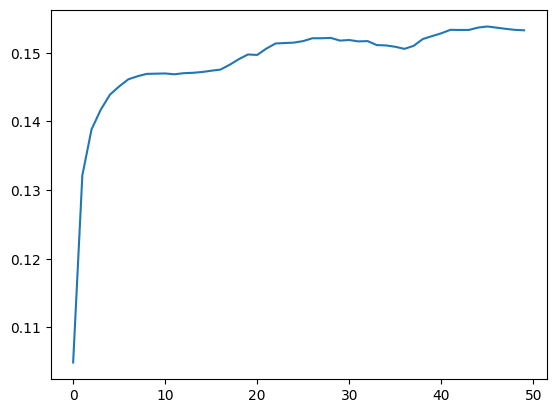

In [16]:
history_df['recall'].to_pandas().plot()

In [17]:
compiled_graph.eval()
valid_metrics = evaluate_model(
    graph_module=compiled_graph,
    histories=valid_histories,
    targets=valid_targets,
    item_to_token_id=item_to_token_id,
    catalog_size=train.get_column("item_id").n_unique(),
    topk=TOPK,
    batch_size=128,
)

valid_metrics

{'hitrate': 0.4214653831688301,
 'recall': 0.15382154896271014,
 'ndcg': np.float64(0.05989463750274985),
 'coverage': 0.10647189408175976}

In [18]:
test_metrics = evaluate_model(
    graph_module=compiled_graph,
    histories=test_histories,
    targets=test_targets,
    item_to_token_id=item_to_token_id,
    catalog_size=train.get_column("item_id").n_unique(),
    topk=TOPK,
    batch_size=128,
)

test_metrics

{'hitrate': 0.39946985855992045,
 'recall': 0.1412030684970568,
 'ndcg': np.float64(0.053843498988774406),
 'coverage': 0.10647011955019174}